# MOT

Simulating a MOT with `atomsmltr`

In [1]:
# - Packages
import numpy as np
import matplotlib.pyplot as plt

# - atomSmltr
from atomsmltr.atoms import Ytterbium
from atomsmltr.environment.lasers import GaussianLaserBeam
from atomsmltr.environment.fields import MagneticQuadrupoleZ, MagneticOffset
from atomsmltr.environment.zones import Box, Limits
from atomsmltr.simulation import Configuration, ScipyIVP_3D
from atomsmltr.environment.lasers.polarization import CircularLeft, CircularRight, Vector

### global config

In [2]:
# - Init global config
config = Configuration(atom=Ytterbium())
main = config.atom.trans["main"]

# - setup magnetic field
B_grad_G_per_cm = 30
B_grad = B_grad_G_per_cm * 1e-4 / 1e-2
mag_quad = MagneticQuadrupoleZ(origin=(0, 0, 0), slope=B_grad, tag="MOT field")

# - setup lasers
# cf. config from Letellier et al. 2023
l399 = {"wavelength":399e-9, "waist":22e-3, "power": 100e-3/6, "waist_position":(0,0,0)}
lasers = {}
for axis, direction in zip(["x", "y", "z"], [(1, 0, 0), (0, 1, 0), (0,0,1)]):
    for head, mult in zip([">", "<"], [1, -1]):
        dir = np.array(direction) * mult
        tag = axis + head
        laser = GaussianLaserBeam(**l399)
        laser.direction = dir
        laser.tag = tag
        lasers[tag] = laser

# check that s ~ 0.037
s = lasers["x>"].get_intensity((0,0,0)) / main.Isat
print(f"I = {s:.3f} I_sat")

I = 0.037 I_sat


### 1D test

#### laser polarization illustration

We set the polarization of the laser beams and check their projections on the local magnetic field. Here, we always define the quantization axis with respect to the local magnetic field direction. 

Here, the magnetic field gradient is positive along x.

Hence, the laser propagating in the +x direction, labeled "x>" should be "sigma-" for x<0 and "sigma+" for x>0.



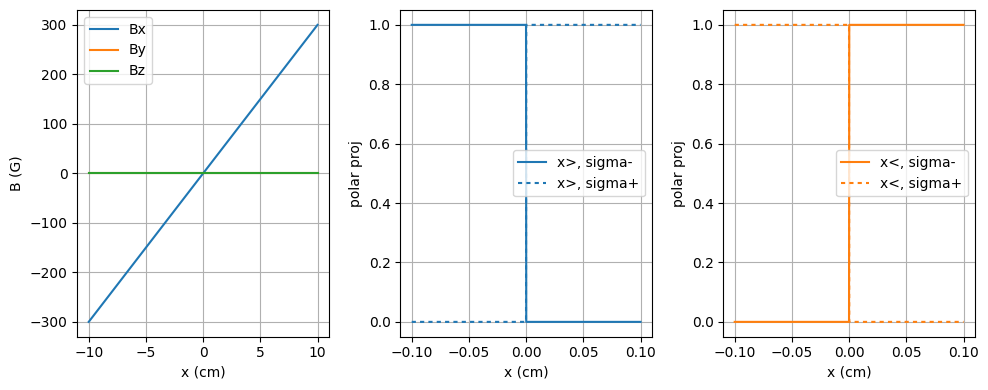

In [3]:
# -- Plot illustration

# set laser polarization
lasers["x>"].polarization = CircularRight()
lasers["x<"].polarization = CircularRight()

# compute mag field
x = np.linspace(-0.1, 0.1, 1000)
r = np.array([[x, 0, 0] for x in x])
B = mag_quad.value(r)
Bx, By, Bz = B.T

# compute laser projection on quant axis
polar_up = lasers["x>"].get_polarization_quant(B)
polar_up_pi, polar_up_sp, polar_up_sm = polar_up.T
polar_dw = lasers["x<"].get_polarization_quant(B)
polar_dw_pi, polar_dw_sp, polar_dw_sm = polar_dw.T

# plot
fig, axes = plt.subplots(1, 3, figsize=(10,4), tight_layout=True)

axes[0].plot(x * 1e2, Bx * 1e4, label="Bx")
axes[0].plot(x * 1e2, By * 1e4, label="By")
axes[0].plot(x * 1e2, By * 1e4, label="Bz")
axes[0].set_xlabel("x (cm)")
axes[0].set_ylabel("B (G)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, polar_up_sm, color="C0", label="x>, sigma-")
axes[1].plot(x, polar_up_sp, color="C0", dashes=[2,2], label="x>, sigma+")
axes[1].set_xlabel("x (cm)")
axes[1].set_ylabel("polar proj")
axes[1].legend()
axes[1].grid()

axes[2].plot(x, polar_dw_sm, color="C1", label="x<, sigma-")
axes[2].plot(x, polar_dw_sp, color="C1", dashes=[2,2], label="x<, sigma+")
axes[2].set_xlabel("x (cm)")
axes[2].set_ylabel("polar proj")
axes[2].legend()
axes[2].grid()
plt.show()

#### good configuration

In [4]:
# -- Testing with a simulation
# init config
config1D = Configuration(atom=Ytterbium())
# set limit
xlim = Limits(-0.15, 0.15, axis=0, target="position", action="stop", tag="xlim")
# add objects
config1D += xlim, lasers["x<"], lasers["x>"], mag_quad
# setup atomlight
for laser in config1D.list_lasers():
    config1D.add_atomlight_coupling(laser=laser, transition="main", detuning=-2*main.Gamma)

# init sim
sim = ScipyIVP_3D(config1D)

In [5]:
# -- Run simulation
# settings
t = np.linspace(0, 0.1, 1000)
v_list = np.linspace(0.5, 30, 20)
u0_list = [(-0.1, 0, 0, vx, 0, 0) for vx in v_list]

# run
sim.u0_list = u0_list
coll = sim.run(t, npools=5, verbose=True)

100%|██████████| 20/20 [00:00<00:00, 40.26it/s]


In [6]:
# -- compute force
grid = np.mgrid[-0.1:0.1:100j, 0:0:1j, 0:0:1j, -10:30:101j, 0:0:1j, 0:0:1j]
grid = np.squeeze(grid)
pos = grid.T
X, _, _, VX, _ ,_ = grid
force = sim.get_force(pos)
FX, FY, FZ = force.T

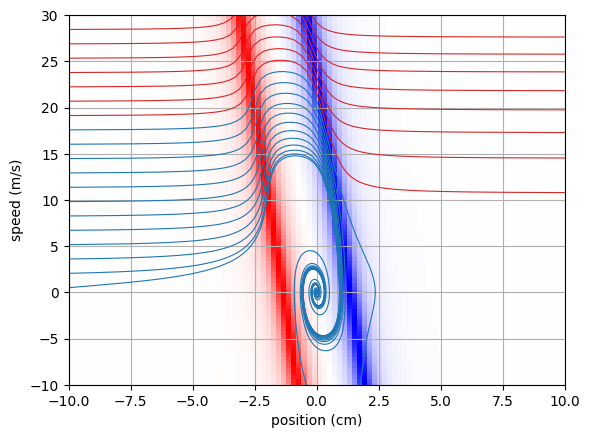

In [7]:

# -- plot
plt.figure()
plt.pcolormesh(X * 100, VX, FX, cmap="bwr")
for res in coll:
    x = res.y[0]
    vx = res.y[3]
    if x[-1] > 0.05:
        color="C3"
    else:
        color="C0"
    plt.plot(x * 100, vx, color=color, linewidth=0.8)
plt.xlim(-10, 10)
plt.ylim(-10, 30)
plt.xlabel("position (cm)")
plt.ylabel("speed (m/s)")
plt.grid()
plt.show()


#### bad polarization

In [8]:
# Invert laser polarization, for fun
lasers["x>"].polarization = CircularLeft()
lasers["x<"].polarization = CircularLeft()
config1D.update_objects([lasers["x>"], lasers["x<"]])

# run
sim.u0_list = u0_list
coll = sim.run(t, npools=3, verbose=True)

100%|██████████| 20/20 [00:00<00:00, 69.52it/s]


In [9]:
# -- compute force
grid = np.mgrid[-0.1:0.1:100j, 0:0:1j, 0:0:1j, -10:30:101j, 0:0:1j, 0:0:1j]
grid = np.squeeze(grid)
pos = grid.T
X, _, _, VX, _ ,_ = grid
force = sim.get_force(pos)
FX, FY, FZ = force.T

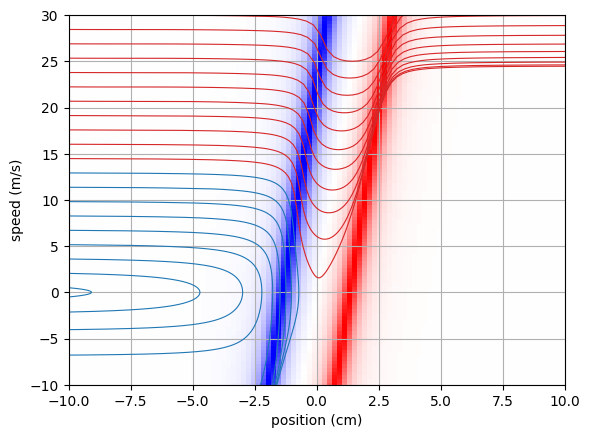

In [10]:
plt.figure()
for res in coll:
    x = res.y[0]
    vx = res.y[3]
    if x[-1] > 0.05:
        color="C3"
    else:
        color="C0"
    plt.plot(x * 100, vx, color=color, linewidth=0.8)
plt.pcolormesh(X * 100, VX, FX, cmap="bwr")
plt.xlim(-10, 10)
plt.ylim(-10, 30)
plt.xlabel("position (cm)")
plt.ylabel("speed (m/s)")
plt.grid()
plt.show()

#### simulation - add offset

In [11]:
# Invert laser polarization, for fun
lasers["x>"].polarization = CircularRight()
lasers["x<"].polarization = CircularRight()
config1D.update_objects([lasers["x>"], lasers["x<"]])

mag_offset = MagneticOffset((30e-4,0,0))
config1D.rm_all_magnetic_fields()
config1D += mag_offset, mag_quad

# run
sim.u0_list = u0_list
coll = sim.run(t, npools=3, verbose=True)

100%|██████████| 20/20 [00:00<00:00, 29.58it/s]


In [12]:
# -- compute force
grid = np.mgrid[-0.1:0.1:100j, 0:0:1j, 0:0:1j, -10:30:101j, 0:0:1j, 0:0:1j]
grid = np.squeeze(grid)
pos = grid.T
X, _, _, VX, _ ,_ = grid
force = sim.get_force(pos)
FX, FY, FZ = force.T

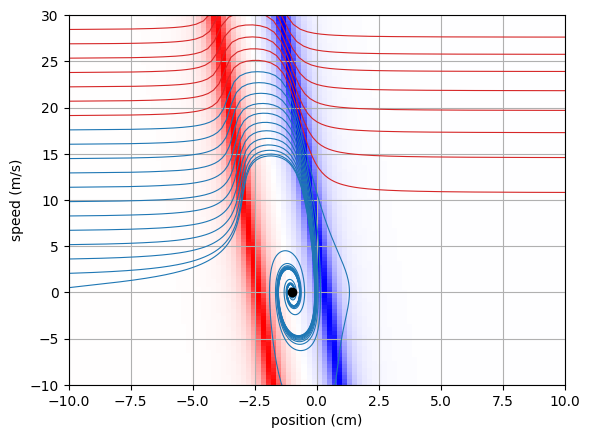

In [13]:
plt.figure()
plt.pcolormesh(X * 100, VX, FX, cmap="bwr")
for res in coll:
    x = res.y[0]
    vx = res.y[3]
    if x[-1] > 0.05:
        color="C3"
    else:
        color="C0"
    plt.plot(x * 100, vx, color=color, linewidth=0.8)
plt.plot(-1, 0, "ok") # new center should be at -1cm, since gradient is 30 G/cm
plt.xlim(-10, 10)
plt.ylim(-10, 30)
plt.xlabel("position (cm)")
plt.ylabel("speed (m/s)")
plt.grid()
plt.show()